In [1]:
!pip install numpy 

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import numpy as np

In [4]:
!pip install pandas 

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd

In [6]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset

In [8]:
df=pd.read_csv(r"C:\Users\Admin\Downloads\archive.zip")
print(df)

      Transaction ID       Date Day of Week  Time Type of Card Entry Mode  \
0          #3577 209  14-Oct-20   Wednesday    19         Visa        Tap   
1          #3039 221  14-Oct-20   Wednesday    17   MasterCard        PIN   
2          #2694 780  14-Oct-20   Wednesday    14         Visa        Tap   
3          #2640 960  13-Oct-20     Tuesday    14         Visa        Tap   
4          #2771 031  13-Oct-20     Tuesday    23         Visa        CVC   
...              ...        ...         ...   ...          ...        ...   
99995      #3203 892  13-Oct-20     Tuesday    22   MasterCard        Tap   
99996      #3304 849  14-Oct-20   Wednesday    23   MasterCard        PIN   
99997      #3532 129  13-Oct-20     Tuesday    11   MasterCard        PIN   
99998      #3107 092  14-Oct-20   Wednesday    22         Visa        Tap   
99999      #3400 711  14-Oct-20   Wednesday    16         Visa        PIN   

      Amount Type of Transaction Merchant Group Country of Transaction  \
0

In [ ]:
# Dataset understand

In [18]:
df.head()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud,risk_score
0,#3577 209,14-Oct-20,Wednesday,19,Visa,Tap,£5,POS,Entertainment,United Kingdom,United Kingdom,United Kingdom,M,25.2,RBS,0,0
1,#3039 221,14-Oct-20,Wednesday,17,MasterCard,PIN,£288,POS,Services,USA,USA,USA,F,49.6,Lloyds,0,0
2,#2694 780,14-Oct-20,Wednesday,14,Visa,Tap,£5,POS,Restaurant,India,India,India,F,42.2,Barclays,0,0
3,#2640 960,13-Oct-20,Tuesday,14,Visa,Tap,£28,POS,Entertainment,United Kingdom,India,United Kingdom,F,51.0,Barclays,0,0
4,#2771 031,13-Oct-20,Tuesday,23,Visa,CVC,£91,Online,Electronics,USA,USA,United Kingdom,M,38.0,Halifax,1,0


In [9]:
df.tail()

,Transaction ID,Date,Day of Week,Time,Type of Card,Entry Mode,Amount,Type of Transaction,Merchant Group,Country of Transaction,Shipping Address,Country of Residence,Gender,Age,Bank,Fraud
99995,#3203 892,13-Oct-20,Tuesday,22,MasterCard,Tap,£15,POS,Electronics,United Kingdom,United Kingdom,United Kingdom,F,53.8,Halifax,0
99996,#3304 849,14-Oct-20,Wednesday,23,MasterCard,PIN,£7,ATM,Children,Russia,Russia,Russia,M,45.0,Barclays,0
99997,#3532 129,13-Oct-20,Tuesday,11,MasterCard,PIN,£21,ATM,Subscription,United Kingdom,United Kingdom,United Kingdom,F,46.5,HSBC,0
99998,#3107 092,14-Oct-20,Wednesday,22,Visa,Tap,£25,POS,Products,United Kingdom,United Kingdom,United Kingdom,M,48.2,Barclays,0
99999,#3400 711,14-Oct-20,Wednesday,16,Visa,PIN,£226,POS,Restaurant,United Kingdom,United Kingdom,United Kingdom,M,31.7,Monzo,0


In [19]:
df.describe()

,Time,Age,Fraud,risk_score
count,100000.000000,100000.000000,100000.000000,100000.0
mean,14.562870,44.993770,0.071950,0.0
std,5.308195,9.948494,0.258406,0.0
min,0.000000,15.000000,0.000000,0.0
25%,10.000000,38.200000,0.000000,0.0
50%,15.000000,44.900000,0.000000,0.0
75%,19.000000,51.700000,0.000000,0.0
max,24.000000,86.100000,1.000000,0.0


In [20]:
df.dtypes

Transaction ID             object
Date                       object
Day of Week                object
Time                        int64
Type of Card               object
Entry Mode                 object
Amount                     object
Type of Transaction        object
Merchant Group             object
Country of Transaction     object
Shipping Address           object
Country of Residence       object
Gender                     object
Age                       float64
Bank                       object
Fraud                       int64
risk_score                  int64
dtype: object

In [21]:
df.shape

(100000, 17)

In [22]:
df.isnull().sum()



Transaction ID             0
Date                       0
Day of Week                0
Time                       0
Type of Card               0
Entry Mode                 0
Amount                     6
Type of Transaction        0
Merchant Group            10
Country of Transaction     0
Shipping Address           5
Country of Residence       0
Gender                     4
Age                        0
Bank                       0
Fraud                      0
risk_score                 0
dtype: int64

In [23]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
Merchant Group,10,0.010
Amount,6,0.006
Shipping Address,5,0.005
Gender,4,0.004
Country of Transaction,0,0.000
Fraud,0,0.000
Bank,0,0.000
Age,0,0.000
Country of Residence,0,0.000
Transaction ID,0,0.000


In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
# Convert Amount from Euro to INR

In [26]:
df["Amount_GBP"] = (
    df["Amount"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.strip()
)

df["Amount_GBP"] = pd.to_numeric(df["Amount_GBP"], errors="coerce")

##
GBP_TO_INR = 129.33

df["Amount_INR"] = df["Amount_GBP"] * GBP_TO_INR

##
df[["Amount", "Amount_GBP", "Amount_INR"]].head(90)

,Amount,Amount_GBP,Amount_INR
0,£5,5.0,646.65
1,£288,288.0,37247.04
2,£5,5.0,646.65
3,£28,28.0,3621.24
4,£91,91.0,11769.03
...,...,...,...
85,£119,119.0,15390.27
86,£25,25.0,3233.25
87,£11,11.0,1422.63
88,£26,26.0,3362.58


In [27]:
df["Amount_INR"].dtype

dtype('float64')

In [ ]:
# Handle missing Amount values

In [28]:
df["Amount_INR"].isnull().sum()

np.int64(6)

In [29]:
df["Amount_INR"] = df["Amount_INR"].fillna(
    df["Amount_INR"].median()
)
print(df["Amount_INR"])

0          646.65
1        37247.04
2          646.65
3         3621.24
4        11769.03
           ...   
99995     1939.95
99996      905.31
99997     2715.93
99998     3233.25
99999    29228.58
Name: Amount_INR, Length: 100000, dtype: float64


In [30]:
# Merchant Group
df["Merchant Group"] = df["Merchant Group"].fillna("Unknown")
print(df["Merchant Group"])
#Shipping Address
df["Shipping Address"] = df["Shipping Address"].fillna("Unknown")
print(df["Shipping Address"])
# Gender
df["Gender"]=df["Gender"].fillna("Unknown")
print(df["Gender"])

0        Entertainment
1             Services
2           Restaurant
3        Entertainment
4          Electronics
             ...      
99995      Electronics
99996         Children
99997     Subscription
99998         Products
99999       Restaurant
Name: Merchant Group, Length: 100000, dtype: object
0        United Kingdom
1                   USA
2                 India
3                 India
4                   USA
              ...      
99995    United Kingdom
99996            Russia
99997    United Kingdom
99998    United Kingdom
99999    United Kingdom
Name: Shipping Address, Length: 100000, dtype: object
0        M
1        F
2        F
3        F
4        M
        ..
99995    F
99996    M
99997    F
99998    M
99999    M
Name: Gender, Length: 100000, dtype: object


In [31]:
df.columns

Index(['Transaction ID', 'Date', 'Day of Week', 'Time', 'Type of Card',
       'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group',
       'Country of Transaction', 'Shipping Address', 'Country of Residence',
       'Gender', 'Age', 'Bank', 'Fraud', 'risk_score', 'Amount_GBP',
       'Amount_INR'],
      dtype='object')

In [32]:
# Convert Date

In [33]:
# ###
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%b-%y",
    errors="coerce"
)

####
df["Date"].min(), df["Date"].max()

####
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
print(df['Date'])

0       2020-10-14
1       2020-10-14
2       2020-10-14
3       2020-10-13
4       2020-10-13
           ...    
99995   2020-10-13
99996   2020-10-14
99997   2020-10-13
99998   2020-10-14
99999   2020-10-14
Name: Date, Length: 100000, dtype: datetime64[ns]


In [34]:
# check transaction ID duplicates

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
df["Transaction ID"].duplicated().sum()

np.int64(4320)

In [37]:
# Quality Analysis
df["Bank"].value_counts()

####
df["Bank"] = df["Bank"].replace({
    "Barlcays": "Barclays"
})

####
df["Bank"].value_counts()

Bank
Barclays    39929
Monzo       10103
RBS         10046
Metro       10012
Halifax      9988
Lloyds       9965
HSBC         9957
Name: count, dtype: int64

In [38]:
# Fraud distribution
How many transactions are fraudulent vs legitimate?

Object `legitimate` not found.


Fraud
0    92805
1     7195
Name: count, dtype: int64
Fraud
0    92.805
1     7.195
Name: proportion, dtype: float64


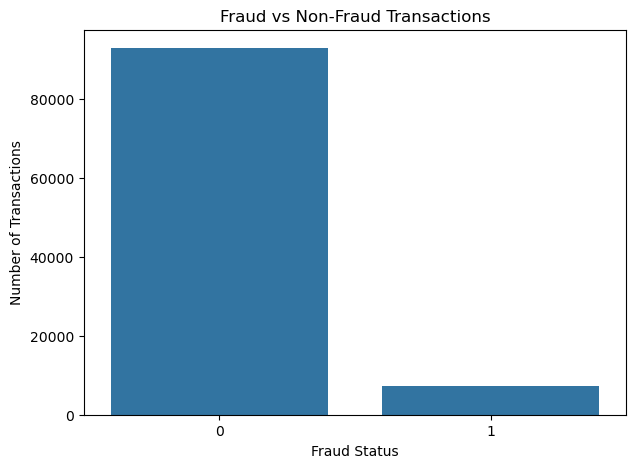

In [39]:
####
fraud_count = df["Fraud"].value_counts()

print(fraud_count)

#### Percentage
fraud_percentage = df["Fraud"].value_counts(normalize=True) * 100

print(fraud_percentage)

#### Visualization
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Fraud")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

In [40]:
# Fraud rate
fraud_rate = df["Fraud"].mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 7.20%


In [41]:
## According to this dataset approx 7.20 are fraudelent which is Flagged.

In [42]:
# Fraud by transaction type
Which transaction type has the highest fraud rate?

Object `rate` not found.


Type of Transaction
Online    9.560646
POS       6.981501
ATM       5.027950
Name: Fraud, dtype: float64


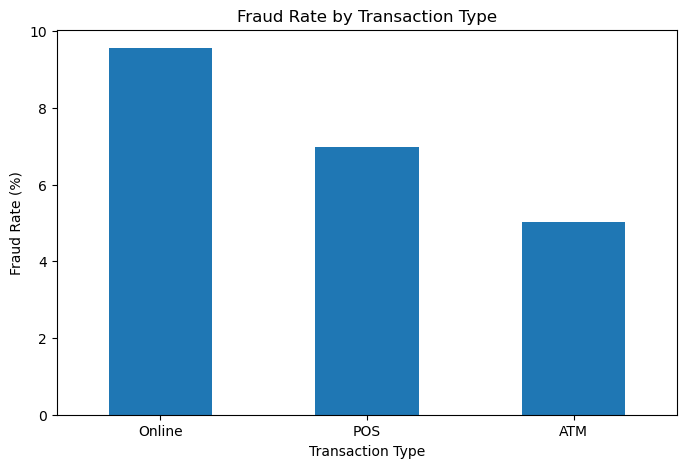

In [43]:
##
fraud_by_transaction = (
    df.groupby("Type of Transaction")["Fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(fraud_by_transaction)


#### Visulization


fraud_by_transaction.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=0)

plt.show()



In [44]:
df.columns

Index(['Transaction ID', 'Date', 'Day of Week', 'Time', 'Type of Card',
       'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group',
       'Country of Transaction', 'Shipping Address', 'Country of Residence',
       'Gender', 'Age', 'Bank', 'Fraud', 'risk_score', 'Amount_GBP',
       'Amount_INR', 'Year', 'Month', 'Month_Name', 'Day'],
      dtype='object')

In [45]:
# Fraud by Entry Mode
Which entry mode is most vulnerable to fraud?

Object `fraud` not found.


Entry Mode
Tap    11.170888
CVC     9.560646
PIN     4.294061
Name: Fraud, dtype: float64


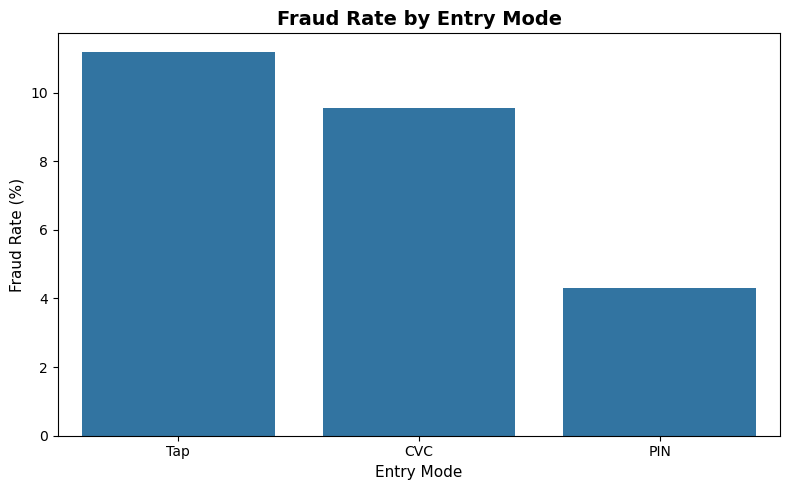

In [46]:
##
# Fraud Rate by Entry Mode

fraud_by_entry = (
    df.groupby("Entry Mode")["Fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

print(fraud_by_entry)


# Visualization

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_by_entry.index,
    y=fraud_by_entry.values
)

plt.title("Fraud Rate by Entry Mode", fontsize=14, fontweight="bold")
plt.xlabel("Entry Mode", fontsize=11)
plt.ylabel("Fraud Rate (%)", fontsize=11)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [47]:
# Fraud by card type

Type of Card
MasterCard    6.224560
Visa          8.027949
Name: Fraud, dtype: float64


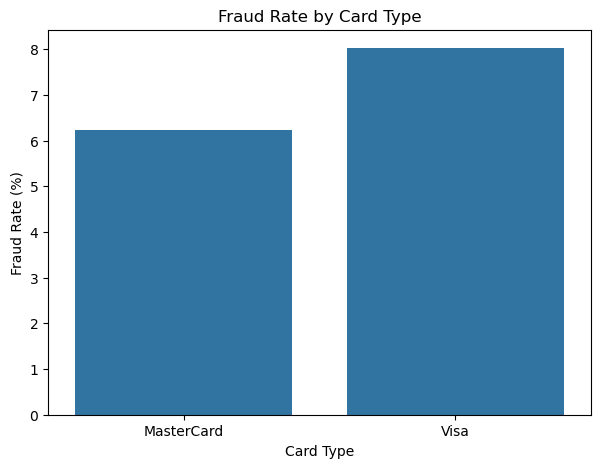

In [48]:
###
fraud_by_card = (
    df.groupby("Type of Card")["Fraud"]
    .mean()
    .mul(100)
)

print(fraud_by_card)


#### Visulization

plt.figure(figsize=(7,5))

sns.barplot(
    x=fraud_by_card.index,
    y=fraud_by_card.values
)

plt.title("Fraud Rate by Card Type")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Card Type")

plt.show()


In [49]:
# Fraud by bank

Bank
Metro       8.040352
Barclays    7.473265
Monzo       7.205780
Lloyds      6.954340
Halifax     6.808170
HSBC        6.558200
RBS         6.490145
Name: Fraud, dtype: float64


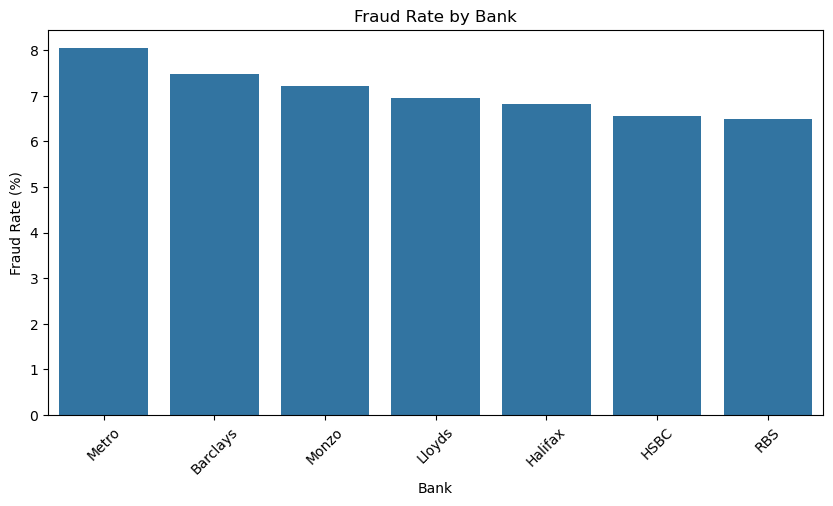

In [50]:
####
fraud_by_bank = (
    df.groupby("Bank")["Fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(fraud_by_bank)

#### Visual
plt.figure(figsize=(10,5))

sns.barplot(
    x=fraud_by_bank.index,
    y=fraud_by_bank.values
)

plt.title("Fraud Rate by Bank")
plt.xlabel("Bank")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [51]:
# Transaction amount analysis
What is the average transaction amount?

Object `amount` not found.


In [52]:
print("Average:", df["Amount_INR"].mean())
print("Median:", df["Amount_INR"].median())
print("Maximum:", df["Amount_INR"].max())
print("Minimum:", df["Amount_INR"].min())

Average: 14559.1385148
Median: 3879.9000000000005
Maximum: 51732.00000000001
Minimum: 646.6500000000001


In [ ]:
# Fraudulent vs non-fraudulent amount
Do fraudulent transactions have higher transaction amounts?

       count          mean   median     min      max           sum
Fraud                                                             
0      92805  15047.419034  4138.56  646.65  51732.0  1.396476e+09
1       7195   8261.032391  2715.93  646.65  51732.0  5.943813e+07


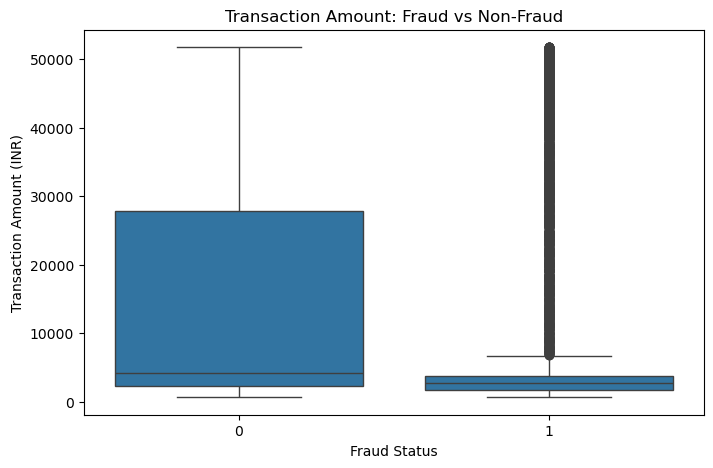

In [53]:
####
amount_fraud = df.groupby("Fraud")["Amount_INR"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max",
    "sum"
])

print(amount_fraud)


#### Visual

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Fraud",
    y="Amount_INR"
)

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount (INR)")

plt.show()


In [ ]:
# Fraud by Merchant Group

Merchant Group
Children         11.986141
Electronics      10.127625
Fashion           9.252028
Entertainment     5.996544
Services          5.919936
Food              5.869808
Gaming            5.823594
Products          5.722126
Subscription      5.612910
Restaurant        5.358206
Unknown           0.000000
Name: Fraud, dtype: float64


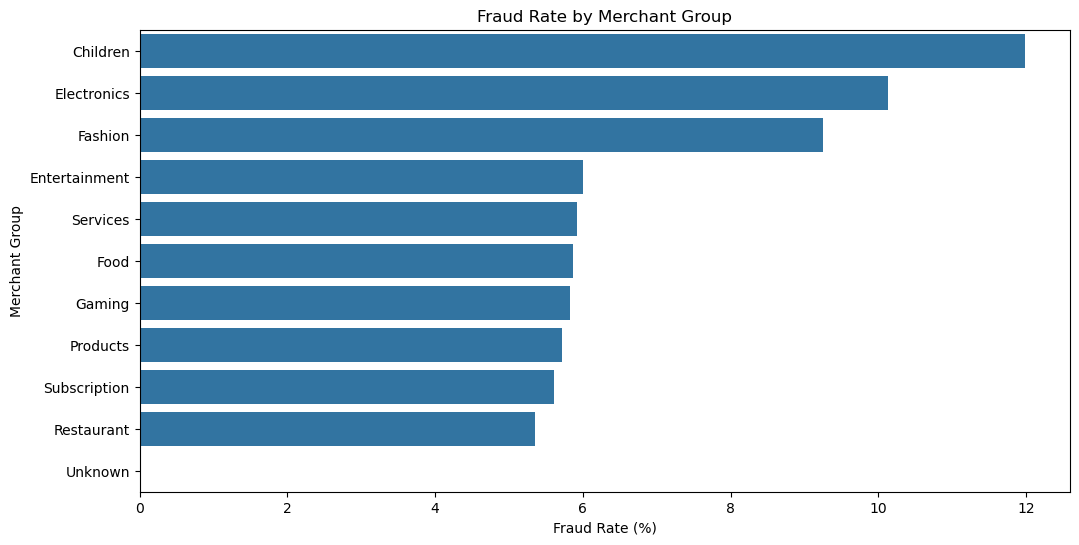

In [54]:
####
fraud_by_merchant = (
    df.groupby("Merchant Group")["Fraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(fraud_by_merchant)


#### Visual

plt.figure(figsize=(12,6))

sns.barplot(
    x=fraud_by_merchant.values,
    y=fraud_by_merchant.index
)

plt.title("Fraud Rate by Merchant Group")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Merchant Group")

plt.show()

In [55]:
# Country-wise fraud analysis
Which countries have the highest fraud rate?

Object `rate` not found.


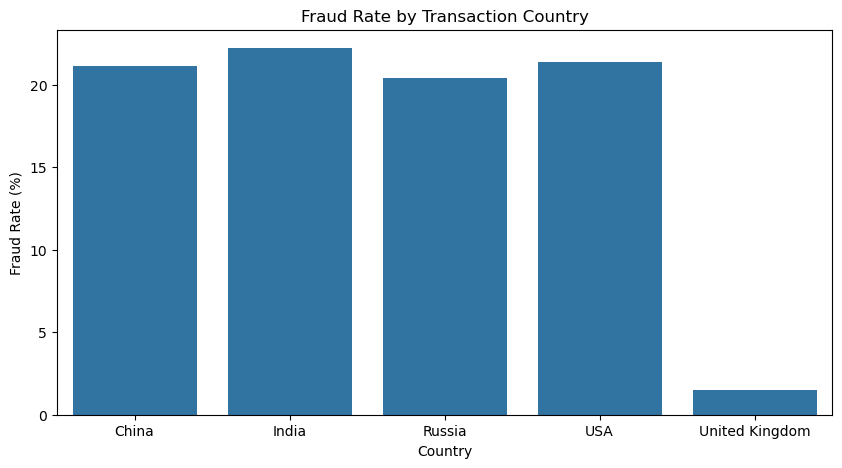

In [56]:
####
country_fraud = (
    df.groupby("Country of Transaction")["Fraud"]
    .agg(["count", "sum", "mean"])
)

country_fraud["Fraud_Rate"] = country_fraud["mean"] * 100

country_fraud.sort_values(
    "Fraud_Rate",
    ascending=False
)



#### Visual
plt.figure(figsize=(10,5))

sns.barplot(
    data=country_fraud.reset_index(),
    x="Country of Transaction",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Transaction Country")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Country")

plt.show()

In [57]:
# Transaction country vs residence country
Are transactions more fraudulent when the transaction country differs from the customer's residence country?

SyntaxError: unterminated string literal (detected at line 2) (681522816.py, line 2)

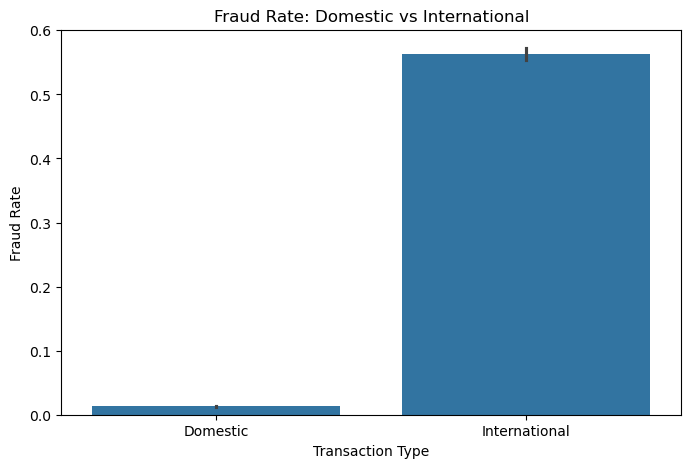

In [58]:
###
df["International_Transaction"] = np.where(
    df["Country of Transaction"] != df["Country of Residence"],
    "International",
    "Domestic"
)


###
df.groupby("International_Transaction")["Fraud"].agg(
    ["count", "sum", "mean"]
)


### Fraud rate
df.groupby("International_Transaction")["Fraud"].mean() * 100




#### Visual
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="International_Transaction",
    y="Fraud"
)

plt.title("Fraud Rate: Domestic vs International")
plt.ylabel("Fraud Rate")
plt.xlabel("Transaction Type")

plt.show()

In [ ]:
# Shipping address mismatch
Does a mismatch between shipping address and transaction country indicate higher fraud risk?

In [59]:
###
df["Shipping_Mismatch"] = np.where(
    df["Country of Transaction"] != df["Shipping Address"],
    "Mismatch",
    "Match"
)


###
df.groupby("Shipping_Mismatch")["Fraud"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Shipping_Mismatch,,,
Match,87943,6009,0.068328
Mismatch,12057,1186,0.098366


In [ ]:
# Fraud by age

Age_Group
Under 18    7.065217
18-25       7.429130
26-35       7.139741
36-45       7.230349
46-55       7.188229
56-65       7.187941
65+         6.933333
Name: Fraud, dtype: float64


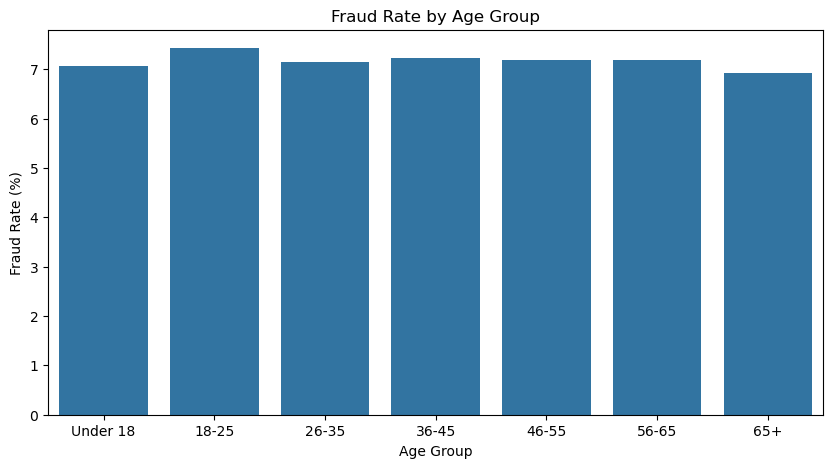

In [62]:
## First Create age group
bins = [0, 18, 25, 35, 45, 55, 65, 100]

labels = [
    "Under 18",
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)


## fraud Analysis according to Age
age_fraud = (
    df.groupby("Age_Group", observed=True)["Fraud"]
    .mean()
    .mul(100)
)

print(age_fraud)



### Visual

plt.figure(figsize=(10,5))

sns.barplot(
    x=age_fraud.index,
    y=age_fraud.values
)

plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [ ]:
# Gender analysis

In [60]:
gender_analysis = df.groupby("Gender").agg(
    Transactions=("Transaction ID", "count"),
    Fraud_Transactions=("Fraud", "sum"),
    Average_Amount=("Amount_INR", "mean")
)

gender_analysis["Fraud_Rate"] = (
    gender_analysis["Fraud_Transactions"] /
    gender_analysis["Transactions"] * 100
)

gender_analysis

,Transactions,Fraud_Transactions,Average_Amount,Fraud_Rate
Gender,,,,
F,49121,2919,14563.699093,5.942469
M,50875,4276,14554.283422,8.404914
Unknown,4,0,20304.810000,0.000000


In [ ]:
# Time analysis
At which hours do most fraudulent transactions occur?

Time
0     100.000000
1     100.000000
2     100.000000
3     100.000000
4     100.000000
5     100.000000
6     100.000000
7       3.655764
8       3.448883
9       3.644524
10      3.796791
11      3.601253
12      3.458464
13      5.662651
14      3.517411
15      3.658751
16      3.509075
17      4.060018
18      3.695025
19      3.290644
20      3.893517
21      3.800141
22      4.055496
23      3.652174
24    100.000000
Name: Fraud, dtype: float64


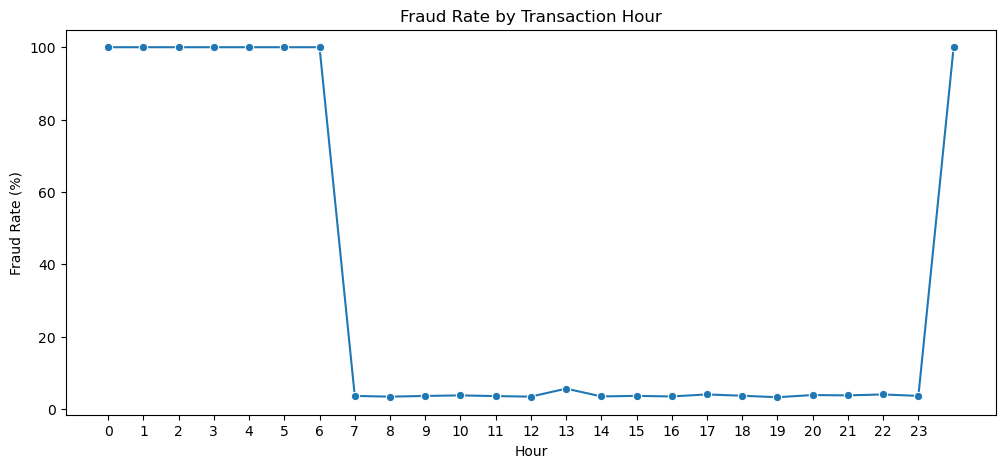

In [64]:
###
hour_fraud = (
    df.groupby("Time")["Fraud"]
    .mean()
    .mul(100)
)

print(hour_fraud)


### Visual

plt.figure(figsize=(12,5))

sns.lineplot(
    x=hour_fraud.index,
    y=hour_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0,24))

plt.show()

In [ ]:
# Day-of-week analysis

Day of Week
Friday        7.142857
Thursday     16.666667
Tuesday       7.496436
Wednesday     6.893597
Name: Fraud, dtype: float64


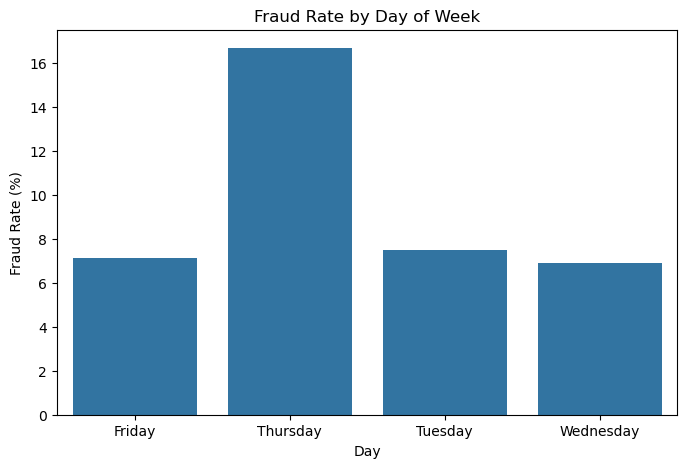

In [61]:
###
day_fraud = (
    df.groupby("Day of Week")["Fraud"]
    .mean()
    .mul(100)
)

print(day_fraud)


### Visual
plt.figure(figsize=(8,5))

sns.barplot(
    x=day_fraud.index,
    y=day_fraud.values
)

plt.title("Fraud Rate by Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.xlabel("Day")

plt.show()

In [ ]:
# Top 10 highest-value transactions

In [62]:
### 
top_transactions = df.nlargest(
    10,
    "Amount_INR"
)

top_transactions[
    [
        "Transaction ID",
        "Amount_INR",
        "Type of Transaction",
        "Merchant Group",
        "Country of Transaction",
        "Fraud"
    ]
]

,Transaction ID,Amount_INR,Type of Transaction,Merchant Group,Country of Transaction,Fraud
2336,#3427 552,51732.0,ATM,Entertainment,United Kingdom,0
2825,#2700 782,51732.0,ATM,Fashion,United Kingdom,0
2971,#3091 120,51732.0,Online,Electronics,United Kingdom,0
4357,#2620 458,51732.0,Online,Subscription,USA,0
4787,#3559 054,51732.0,POS,Products,United Kingdom,0
5952,#3345 515,51732.0,Online,Products,United Kingdom,0
6611,#2836 348,51732.0,Online,Subscription,United Kingdom,0
7048,#3318 275,51732.0,POS,Products,United Kingdom,0
7851,#2950 681,51732.0,POS,Services,China,0
8193,#3102 882,51732.0,ATM,Restaurant,USA,0


In [ ]:
### Highest-value fraudulent transactions

In [63]:
###

top_fraud = (
    df[df["Fraud"] == 1]
    .nlargest(10, "Amount_INR")
)

top_fraud[
    [
        "Transaction ID",
        "Amount_INR",
        "Bank",
        "Type of Transaction",
        "Merchant Group",
        "Country of Transaction"
    ]
]

,Transaction ID,Amount_INR,Bank,Type of Transaction,Merchant Group,Country of Transaction
26132,#3496 378,51732.00,Monzo,Online,Electronics,India
50872,#3294 650,51732.00,Monzo,Online,Products,USA
51983,#3230 152,51732.00,Lloyds,Online,Electronics,USA
64505,#2949 169,51732.00,Barclays,ATM,Children,Russia
74289,#2706 608,51732.00,Barclays,POS,Electronics,India
74701,#3659 359,51732.00,Barclays,ATM,Subscription,USA
78500,#2767 467,51732.00,Metro,ATM,Children,Russia
88707,#2758 521,51732.00,Halifax,POS,Fashion,China
5471,#2974 957,51602.67,Barclays,POS,Fashion,USA
51037,#2854 986,51602.67,Halifax,ATM,Products,India


In [ ]:
## Correlation analysis

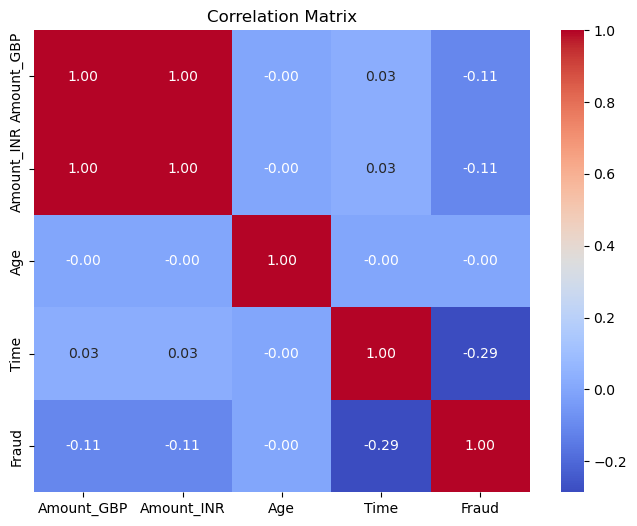

In [64]:
numeric_cols = [
    "Amount_GBP",
    "Amount_INR",
    "Age",
    "Time",
    "Fraud"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
## Outlier analysis

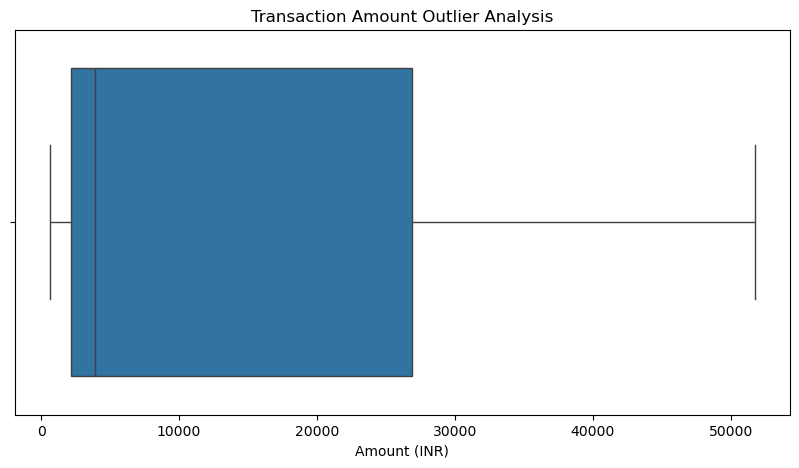

In [65]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=df["Amount_INR"]
)

plt.title("Transaction Amount Outlier Analysis")
plt.xlabel("Amount (INR)")

plt.show()

In [ ]:
# IQR

In [66]:
Q1 = df["Amount_INR"].quantile(0.25)
Q3 = df["Amount_INR"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount_INR"] < lower) |
    (df["Amount_INR"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


In [74]:
df.columns

Index(['Transaction ID', 'Date', 'Day of Week', 'Time', 'Type of Card',
       'Entry Mode', 'Amount', 'Type of Transaction', 'Merchant Group',
       'Country of Transaction', 'Shipping Address', 'Country of Residence',
       'Gender', 'Age', 'Bank', 'Fraud', 'Amount_GBP', 'Amount_INR', 'Year',
       'Month', 'Month_Name', 'Day', 'International_Transaction',
       'Shipping_Mismatch', 'Age_Group'],
      dtype='object')

# Create a Risk Score

In [68]:
df["risk_score"] = 0

df.loc[df["Amount"] > df["Amount"].quantile(0.95),
       "risk_score"] += 1

df.loc[df["Amount_change_pct"] > 200,
       "risk_score"] += 1

df.loc[abs(df["balance_difference"]) > 0.01,
       "risk_score"] += 1

df.loc[df["Fraud"] == 1,
       "risk_score"] += 2

TypeError: unsupported operand type(s) for -: 'str' and 'str'